У цьому домашньому завданні ми будемо працювати з набором даних Tips. Нижче інформація про нього.

**Про датасет:**

Tips - це датасет, який містить інформацію про рахунки та чайові в ресторані.

**Колонки датасету:**
- `total_bill` - загальна сума рахунку (долари)
- `tip` - розмір чайових (долари)
- `sex` - стать відвідувача (Male/Female)
- `smoker` - чи курить (Yes/No)
- `day` - день тижня (Thur/Fri/Sat/Sun)
- `time` - час відвідування (Lunch/Dinner)
- `size` - розмір групи (кількість людей)

**Джерело:** Оригінальні дані зібрані в одному з американських ресторанів у 1990-х роках. Скачати і переглянути набір даних можна тут: https://www.kaggle.com/datasets/sakshisatre/tips-dataset

А також ми вже вивантажили файл з даними і завантажили вам у Матеріали до цього модуля.

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

In [ ]:
df = pd.read_csv('tip.csv')

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4





**1. Гістограма розподілу рахунків**
Завантажте датасет Tips (Чайові) з файла у матеріалах `tips.csv`.
Створіть гістограму для колонки `total_bill` з 20 bins.
Опціонально можна додати підписи осей ОХ, ОУ, а також назву графіку.

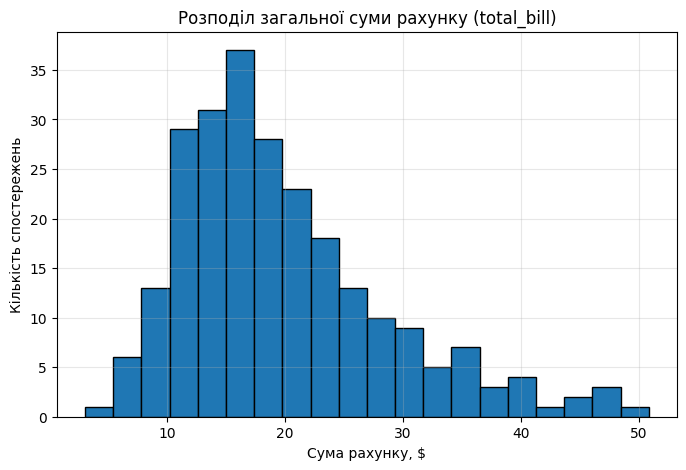

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["total_bill"], bins=20, edgecolor="black")

plt.title("Розподіл загальної суми рахунку (total_bill)")
plt.xlabel("Сума рахунку, $")
plt.ylabel("Кількість спостережень")

plt.grid(alpha=0.3)
plt.show()


---

**2. Box plot чайових за днями тижня**

Створіть box plot, який показує розподіл чайових (`tip`) за днями тижня (`day`).
В який день навище медіанне (середнє) значення чайоивх? Зелена горизонтальна лінія всередині кожного box-plot.


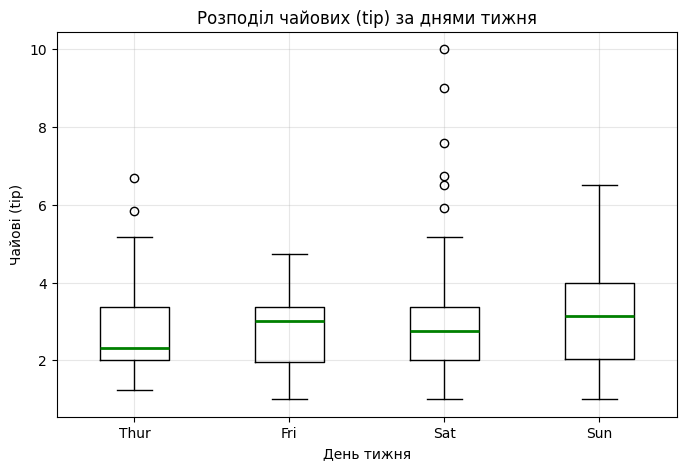

In [19]:
import matplotlib.pyplot as plt

days = ["Thur", "Fri", "Sat", "Sun"]

tips_by_day = [df.loc[df["day"] == d, "tip"] for d in days]

plt.figure(figsize=(8, 5))
plt.boxplot(
    tips_by_day,
    tick_labels=days,
    medianprops=dict(color="green", linewidth=2)
)

plt.title("Розподіл чайових (tip) за днями тижня")
plt.xlabel("День тижня")
plt.ylabel("Чайові (tip)")
plt.grid(alpha=0.3)
plt.show()


---

**3. Scatter plot: рахунок vs чайові**

Створіть діаграму розсіювання для `total_bill` та `tip`.

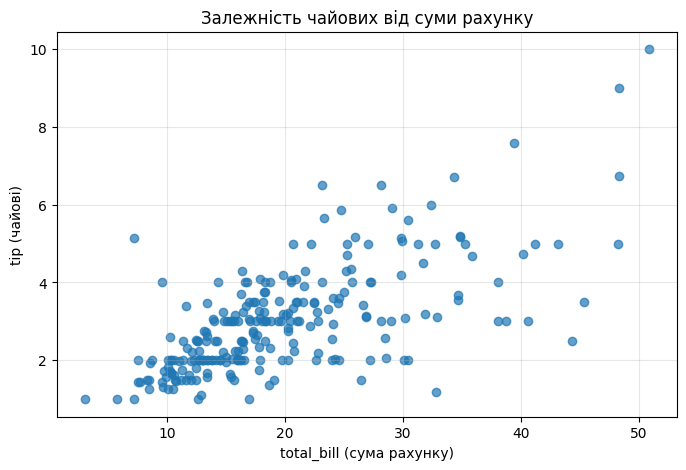

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["total_bill"], df["tip"], alpha=0.7)

plt.title("Залежність чайових від суми рахунку")
plt.xlabel("total_bill (сума рахунку)")
plt.ylabel("tip (чайові)")
plt.grid(alpha=0.3)
plt.show()

---

**4. Bar chart: середній рахунок за часом**

Створіть стовпчасту діаграму середнього рахунку за часом дня (`time`).

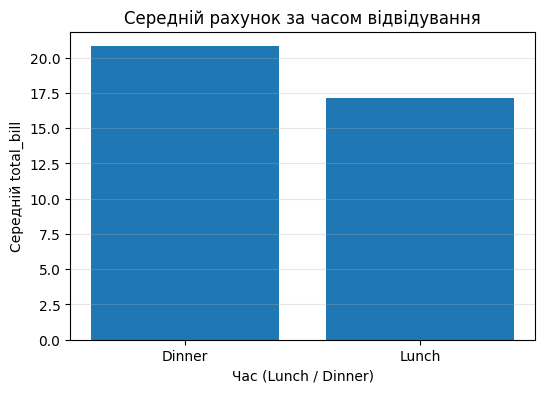

time
Dinner    20.797159
Lunch     17.168676
Name: total_bill, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

avg_bill_by_time = df.groupby("time")["total_bill"].mean()

plt.figure(figsize=(6, 4))
plt.bar(avg_bill_by_time.index, avg_bill_by_time.values)

plt.title("Середній рахунок за часом відвідування")
plt.xlabel("Час (Lunch / Dinner)")
plt.ylabel("Середній total_bill")
plt.grid(axis="y", alpha=0.3)

plt.show()

print(avg_bill_by_time)

---

**5. Інтерактивна діаграма розсіювання**

Створіть з допомогою бібліотек Plotly інтерактивний scatter plot для `total_bill` vs `tip` з кольором за статтю (`sex`).


In [20]:
import plotly.express as px

fig = px.scatter(
    df,
    x="total_bill",
    y="tip",
    color="sex",
    title="Scatter plot: total_bill vs tip (колір = стать)",
    labels={"total_bill": "Сума рахунку", "tip": "Чайові"},
    hover_data=["day", "time", "size"]
)

fig.show()

---

**6. Інтерактивний box plot: чайові за днями та статтю**

Створіть інтерактивний box plot для чайових за днями тижня з розбивкою за кольором по статі.

In [21]:
fig = px.box(
    df,
    x="day",
    y="tip",
    color="sex",
    title="Box plot: розподіл чайових за днями тижня та статтю",
    labels={"day": "День тижня", "tip": "Чайові"},
    category_orders={"day": ["Thur", "Fri", "Sat", "Sun"]}
)

fig.show()
